<a href="https://colab.research.google.com/github/jananagaty/t19/blob/main/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy torch tqdm scikit-learn

In [2]:
import os
import math
import random
import zipfile
import urllib.request
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
zip_path = "ml-1m.zip"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

print("Done")
print(os.listdir("ml-1m"))

Done
['users.dat', 'README', 'movies.dat', 'ratings.dat']


In [5]:
ratings_path = "ml-1m/ratings.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "item_id", "rating", "timestamp"]
)

print(ratings.shape)
ratings.head()

(1000209, 4)


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
ratings = ratings[["user_id", "item_id", "timestamp"]].copy()

print(ratings.shape)
ratings.head()

(1000209, 3)


,user_id,item_id,timestamp
0,1,1193,978300760
1,1,661,978302109
2,1,914,978301968
3,1,3408,978300275
4,1,2355,978824291


In [7]:
user_ids = ratings["user_id"].unique()
item_ids = ratings["item_id"].unique()

user2id = {u: i for i, u in enumerate(user_ids)}
item2id = {i: j for j, i in enumerate(item_ids)}

ratings["user_id"] = ratings["user_id"].map(user2id)
ratings["item_id"] = ratings["item_id"].map(item2id)

num_users = ratings["user_id"].nunique()
num_items = ratings["item_id"].nunique()

print("num_users:", num_users)
print("num_items:", num_items)

num_users: 6040
num_items: 3706


In [8]:
ratings = ratings.sort_values(["user_id", "timestamp"])

train_rows = []
test_rows = []

for user, group in ratings.groupby("user_id"):
    group = group.sort_values("timestamp")

    test_row = group.iloc[-1]
    train_group = group.iloc[:-1]

    test_rows.append(test_row)
    train_rows.append(train_group)

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.DataFrame(test_rows).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (994169, 3)
Test shape: (6040, 3)


In [9]:
user_pos_items = defaultdict(set)

for row in train_df.itertuples():
    user_pos_items[row.user_id].add(row.item_id)

all_items = set(range(num_items))

print("Example user positives:", list(user_pos_items[0])[:10])

Example user positives: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [10]:
test_negatives = {}

for row in tqdm(test_df.itertuples(), total=len(test_df)):
    user = row.user_id
    gt_item = row.item_id

    interacted = set(user_pos_items[user])
    interacted.add(gt_item)

    negatives = []
    while len(negatives) < 99:
        neg_item = random.randint(0, num_items - 1)
        if neg_item not in interacted and neg_item not in negatives:
            negatives.append(neg_item)

    test_negatives[user] = negatives

print("Built test negatives for", len(test_negatives), "users")

100%|██████████| 6040/6040 [00:00<00:00, 8313.99it/s]

Built test negatives for 6040 users


In [11]:
class NCFTrainDataset(Dataset):
    def __init__(self, train_df, num_items, user_pos_items, num_negatives=4):
        self.train_df = train_df
        self.num_items = num_items
        self.user_pos_items = user_pos_items
        self.num_negatives = num_negatives

        self.users = train_df["user_id"].values
        self.items = train_df["item_id"].values

        self.features = []
        self.labels = []

    def ng_sample(self):
        self.features = []
        self.labels = []

        for user, item in zip(self.users, self.items):
            # positive
            self.features.append((user, item))
            self.labels.append(1.0)

            # negatives
            for _ in range(self.num_negatives):
                neg_item = random.randint(0, self.num_items - 1)
                while neg_item in self.user_pos_items[user]:
                    neg_item = random.randint(0, self.num_items - 1)
                self.features.append((user, neg_item))
                self.labels.append(0.0)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        user, item = self.features[idx]
        label = self.labels[idx]
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(item, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [12]:
def hit_ratio(ranklist, gt_item):
    return 1 if gt_item in ranklist else 0

def ndcg(ranklist, gt_item):
    if gt_item in ranklist:
        index = ranklist.index(gt_item)
        return math.log(2) / math.log(index + 2)
    return 0

def evaluate_model(model, test_df, test_negatives, top_k=10):
    model.eval()

    HR, NDCG = [], []

    with torch.no_grad():
        for row in test_df.itertuples():
            user = row.user_id
            gt_item = row.item_id

            items = test_negatives[user] + [gt_item]
            users = [user] * len(items)

            user_tensor = torch.tensor(users, dtype=torch.long).to(device)
            item_tensor = torch.tensor(items, dtype=torch.long).to(device)

            scores = model(user_tensor, item_tensor)
            scores = scores.view(-1).cpu().numpy()

            item_score_dict = {item: score for item, score in zip(items, scores)}
            ranklist = sorted(item_score_dict, key=item_score_dict.get, reverse=True)[:top_k]

            HR.append(hit_ratio(ranklist, gt_item))
            NDCG.append(ndcg(ranklist, gt_item))

    return np.mean(HR), np.mean(NDCG)

In [13]:
class GMF(nn.Module):
    def __init__(self, num_users, num_items, factors=8):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, factors)
        self.item_embedding = nn.Embedding(num_items, factors)
        self.output = nn.Linear(factors, 1)

        self._init_weight_()

    def _init_weight_(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        nn.init.kaiming_uniform_(self.output.weight, a=1, nonlinearity='sigmoid')
        nn.init.zeros_(self.output.bias)

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = user_emb * item_emb
        logits = self.output(x)
        return logits.squeeze(-1)

In [14]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, layers=[64, 32, 16, 8]):
        super().__init__()

        embedding_dim = layers[0] // 2

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        mlp_layers = []
        input_size = layers[0]

        for output_size in layers[1:]:
            mlp_layers.append(nn.Linear(input_size, output_size))
            mlp_layers.append(nn.ReLU())
            input_size = output_size

        self.mlp = nn.Sequential(*mlp_layers)
        self.output = nn.Linear(layers[-1], 1)

        self._init_weight_()

    def _init_weight_(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        nn.init.kaiming_uniform_(self.output.weight, a=1, nonlinearity='sigmoid')
        nn.init.zeros_(self.output.bias)

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=-1)
        x = self.mlp(x)
        logits = self.output(x)
        return logits.squeeze(-1)

In [15]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, factors=8, layers=[64, 32, 16, 8]):
        super().__init__()

        mlp_embedding_dim = layers[0] // 2

        # GMF part
        self.gmf_user_embedding = nn.Embedding(num_users, factors)
        self.gmf_item_embedding = nn.Embedding(num_items, factors)

        # MLP part
        self.mlp_user_embedding = nn.Embedding(num_users, mlp_embedding_dim)
        self.mlp_item_embedding = nn.Embedding(num_items, mlp_embedding_dim)

        mlp_modules = []
        input_size = layers[0]
        for output_size in layers[1:]:
            mlp_modules.append(nn.Linear(input_size, output_size))
            mlp_modules.append(nn.ReLU())
            input_size = output_size

        self.mlp_layers = nn.Sequential(*mlp_modules)

        predict_size = factors + layers[-1]
        self.output = nn.Linear(predict_size, 1)

        self._init_weight_()

    def _init_weight_(self):
        nn.init.normal_(self.gmf_user_embedding.weight, std=0.01)
        nn.init.normal_(self.gmf_item_embedding.weight, std=0.01)
        nn.init.normal_(self.mlp_user_embedding.weight, std=0.01)
        nn.init.normal_(self.mlp_item_embedding.weight, std=0.01)

        for m in self.mlp_layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        nn.init.kaiming_uniform_(self.output.weight, a=1, nonlinearity='sigmoid')
        nn.init.zeros_(self.output.bias)

    def forward(self, user, item):
        # GMF
        gmf_user = self.gmf_user_embedding(user)
        gmf_item = self.gmf_item_embedding(item)
        gmf_vector = gmf_user * gmf_item

        # MLP
        mlp_user = self.mlp_user_embedding(user)
        mlp_item = self.mlp_item_embedding(item)
        mlp_vector = torch.cat([mlp_user, mlp_item], dim=-1)
        mlp_vector = self.mlp_layers(mlp_vector)

        # Combine
        concat = torch.cat([gmf_vector, mlp_vector], dim=-1)
        logits = self.output(concat)
        return logits.squeeze(-1)

    def load_pretrained(self, gmf_model, mlp_model):
        self.gmf_user_embedding.weight.data.copy_(gmf_model.user_embedding.weight.data)
        self.gmf_item_embedding.weight.data.copy_(gmf_model.item_embedding.weight.data)

        self.mlp_user_embedding.weight.data.copy_(mlp_model.user_embedding.weight.data)
        self.mlp_item_embedding.weight.data.copy_(mlp_model.item_embedding.weight.data)

        # copy MLP hidden layers
        self_mlp_linears = [m for m in self.mlp_layers if isinstance(m, nn.Linear)]
        mlp_linears = [m for m in mlp_model.mlp if isinstance(m, nn.Linear)]

        for self_layer, old_layer in zip(self_mlp_linears, mlp_linears):
            self_layer.weight.data.copy_(old_layer.weight.data)
            self_layer.bias.data.copy_(old_layer.bias.data)

In [16]:
def train_model(model, train_df, test_df, test_negatives, num_items, user_pos_items,
                epochs=10, batch_size=256, lr=0.001, num_negatives=4, model_name="Model"):

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_dataset = NCFTrainDataset(
        train_df=train_df,
        num_items=num_items,
        user_pos_items=user_pos_items,
        num_negatives=num_negatives
    )

    best_hr = 0
    best_ndcg = 0

    for epoch in range(epochs):
        model.train()
        train_dataset.ng_sample()

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )

        total_loss = 0

        for user, item, label in train_loader:
            user = user.to(device)
            item = item.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            logits = model(user, item)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        hr, ndcg_score = evaluate_model(model, test_df, test_negatives, top_k=10)

        if hr > best_hr:
            best_hr = hr
            best_ndcg = ndcg_score

        print(
            f"{model_name} | Epoch {epoch+1:02d} | "
            f"Loss = {total_loss/len(train_loader):.4f} | "
            f"HR@10 = {hr:.4f} | NDCG@10 = {ndcg_score:.4f}"
        )

    print(f"\nBest {model_name} Results -> HR@10: {best_hr:.4f}, NDCG@10: {best_ndcg:.4f}")
    return model, best_hr, best_ndcg

In [17]:
mlp_model = MLP(
    num_users=num_users,
    num_items=num_items,
    layers=[64, 32, 16, 8]
)

mlp_model, mlp_hr, mlp_ndcg = train_model(
    model=mlp_model,
    train_df=train_df,
    test_df=test_df,
    test_negatives=test_negatives,
    num_items=num_items,
    user_pos_items=user_pos_items,
    epochs=10,
    batch_size=256,
    lr=0.001,
    num_negatives=4,
    model_name="MLP"
)

MLP | Epoch 01 | Loss = 0.3440 | HR@10 = 0.5435 | NDCG@10 = 0.2954
MLP | Epoch 02 | Loss = 0.3014 | HR@10 = 0.5925 | NDCG@10 = 0.3325
MLP | Epoch 03 | Loss = 0.2844 | HR@10 = 0.6180 | NDCG@10 = 0.3494
MLP | Epoch 04 | Loss = 0.2748 | HR@10 = 0.6311 | NDCG@10 = 0.3612
MLP | Epoch 05 | Loss = 0.2680 | HR@10 = 0.6379 | NDCG@10 = 0.3682
MLP | Epoch 06 | Loss = 0.2629 | HR@10 = 0.6475 | NDCG@10 = 0.3769
MLP | Epoch 07 | Loss = 0.2590 | HR@10 = 0.6454 | NDCG@10 = 0.3754
MLP | Epoch 08 | Loss = 0.2556 | HR@10 = 0.6515 | NDCG@10 = 0.3827
MLP | Epoch 09 | Loss = 0.2529 | HR@10 = 0.6502 | NDCG@10 = 0.3800
MLP | Epoch 10 | Loss = 0.2509 | HR@10 = 0.6503 | NDCG@10 = 0.3829

Best MLP Results -> HR@10: 0.6515, NDCG@10: 0.3827


In [18]:
gmf_model = GMF(
    num_users=num_users,
    num_items=num_items,
    factors=8
)

gmf_model, gmf_hr, gmf_ndcg = train_model(
    model=gmf_model,
    train_df=train_df,
    test_df=test_df,
    test_negatives=test_negatives,
    num_items=num_items,
    user_pos_items=user_pos_items,
    epochs=10,
    batch_size=256,
    lr=0.001,
    num_negatives=4,
    model_name="GMF"
)

GMF | Epoch 01 | Loss = 0.3615 | HR@10 = 0.5137 | NDCG@10 = 0.2828
GMF | Epoch 02 | Loss = 0.3122 | HR@10 = 0.5604 | NDCG@10 = 0.3126
GMF | Epoch 03 | Loss = 0.2930 | HR@10 = 0.5980 | NDCG@10 = 0.3346
GMF | Epoch 04 | Loss = 0.2800 | HR@10 = 0.6118 | NDCG@10 = 0.3482
GMF | Epoch 05 | Loss = 0.2750 | HR@10 = 0.6248 | NDCG@10 = 0.3547
GMF | Epoch 06 | Loss = 0.2729 | HR@10 = 0.6303 | NDCG@10 = 0.3577
GMF | Epoch 07 | Loss = 0.2720 | HR@10 = 0.6368 | NDCG@10 = 0.3630
GMF | Epoch 08 | Loss = 0.2710 | HR@10 = 0.6334 | NDCG@10 = 0.3604
GMF | Epoch 09 | Loss = 0.2703 | HR@10 = 0.6396 | NDCG@10 = 0.3625
GMF | Epoch 10 | Loss = 0.2698 | HR@10 = 0.6399 | NDCG@10 = 0.3631

Best GMF Results -> HR@10: 0.6399, NDCG@10: 0.3631


In [19]:
neumf_model = NeuMF(
    num_users=num_users,
    num_items=num_items,
    factors=8,
    layers=[64, 32, 16, 8]
)

neumf_model, neumf_hr, neumf_ndcg = train_model(
    model=neumf_model,
    train_df=train_df,
    test_df=test_df,
    test_negatives=test_negatives,
    num_items=num_items,
    user_pos_items=user_pos_items,
    epochs=10,
    batch_size=256,
    lr=0.001,
    num_negatives=4,
    model_name="NeuMF-scratch"
)

NeuMF-scratch | Epoch 01 | Loss = 0.3206 | HR@10 = 0.5879 | NDCG@10 = 0.3319
NeuMF-scratch | Epoch 02 | Loss = 0.2757 | HR@10 = 0.6373 | NDCG@10 = 0.3624
NeuMF-scratch | Epoch 03 | Loss = 0.2660 | HR@10 = 0.6497 | NDCG@10 = 0.3728
NeuMF-scratch | Epoch 04 | Loss = 0.2608 | HR@10 = 0.6556 | NDCG@10 = 0.3790
NeuMF-scratch | Epoch 05 | Loss = 0.2566 | HR@10 = 0.6637 | NDCG@10 = 0.3861
NeuMF-scratch | Epoch 06 | Loss = 0.2536 | HR@10 = 0.6690 | NDCG@10 = 0.3925
NeuMF-scratch | Epoch 07 | Loss = 0.2509 | HR@10 = 0.6700 | NDCG@10 = 0.3921
NeuMF-scratch | Epoch 08 | Loss = 0.2482 | HR@10 = 0.6684 | NDCG@10 = 0.3933
NeuMF-scratch | Epoch 09 | Loss = 0.2463 | HR@10 = 0.6674 | NDCG@10 = 0.3940
NeuMF-scratch | Epoch 10 | Loss = 0.2443 | HR@10 = 0.6728 | NDCG@10 = 0.3981

Best NeuMF-scratch Results -> HR@10: 0.6728, NDCG@10: 0.3981


In [20]:
pre_neumf_model = NeuMF(
    num_users=num_users,
    num_items=num_items,
    factors=8,
    layers=[64, 32, 16, 8]
)

pre_neumf_model.load_pretrained(gmf_model, mlp_model)

pre_neumf_model, pre_neumf_hr, pre_neumf_ndcg = train_model(
    model=pre_neumf_model,
    train_df=train_df,
    test_df=test_df,
    test_negatives=test_negatives,
    num_items=num_items,
    user_pos_items=user_pos_items,
    epochs=10,
    batch_size=256,
    lr=0.001,
    num_negatives=4,
    model_name="NeuMF-pretrained"
)

NeuMF-pretrained | Epoch 01 | Loss = 0.2473 | HR@10 = 0.6596 | NDCG@10 = 0.3878
NeuMF-pretrained | Epoch 02 | Loss = 0.2443 | HR@10 = 0.6639 | NDCG@10 = 0.3894
NeuMF-pretrained | Epoch 03 | Loss = 0.2420 | HR@10 = 0.6659 | NDCG@10 = 0.3935
NeuMF-pretrained | Epoch 04 | Loss = 0.2402 | HR@10 = 0.6710 | NDCG@10 = 0.3952
NeuMF-pretrained | Epoch 05 | Loss = 0.2379 | HR@10 = 0.6720 | NDCG@10 = 0.3949
NeuMF-pretrained | Epoch 06 | Loss = 0.2364 | HR@10 = 0.6679 | NDCG@10 = 0.3949
NeuMF-pretrained | Epoch 07 | Loss = 0.2350 | HR@10 = 0.6785 | NDCG@10 = 0.3997
NeuMF-pretrained | Epoch 08 | Loss = 0.2338 | HR@10 = 0.6705 | NDCG@10 = 0.3976
NeuMF-pretrained | Epoch 09 | Loss = 0.2325 | HR@10 = 0.6781 | NDCG@10 = 0.4010
NeuMF-pretrained | Epoch 10 | Loss = 0.2314 | HR@10 = 0.6725 | NDCG@10 = 0.4005

Best NeuMF-pretrained Results -> HR@10: 0.6785, NDCG@10: 0.3997


In [21]:
results = pd.DataFrame({
    "Model": ["GMF", "MLP", "NeuMF-scratch", "NeuMF-pretrained"],
    "HR@10": [gmf_hr, mlp_hr, neumf_hr, pre_neumf_hr],
    "NDCG@10": [gmf_ndcg, mlp_ndcg, neumf_ndcg, pre_neumf_ndcg]
})

results.sort_values("HR@10", ascending=False)

,Model,HR@10,NDCG@10
3,NeuMF-pretrained,0.678477,0.399698
2,NeuMF-scratch,0.672848,0.398069
1,MLP,0.651490,0.382730
0,GMF,0.639901,0.363142


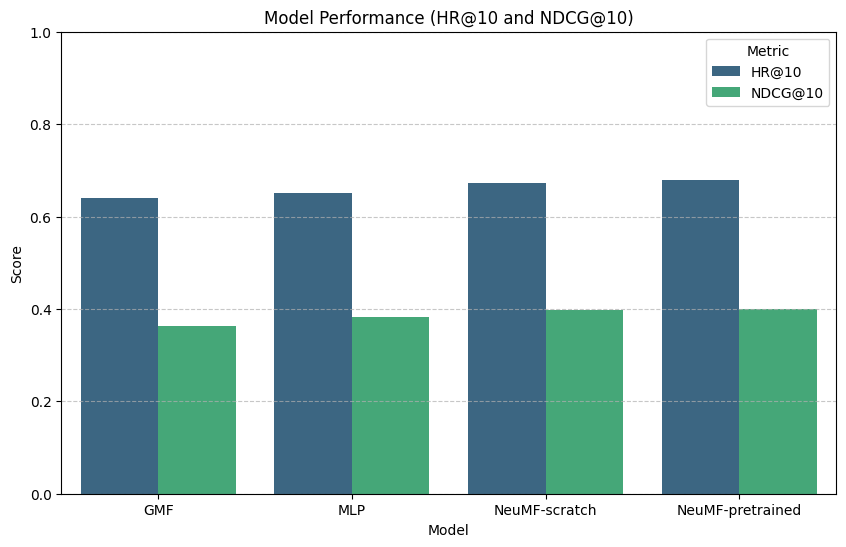

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Performance (HR@10 and NDCG@10)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1) # Scores are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()